## AI-Based Early Chronic Disease Prediction System (Healthcare)

###  Problem Statement

Many patients are diagnosed with chronic diseases such as diabetes, heart disease, and cancer at later stages due to lack of early screening systems, leading to higher treatment costs and mortality rates.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [3]:
data = pd.read_csv("diabetes.csv")



In [4]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


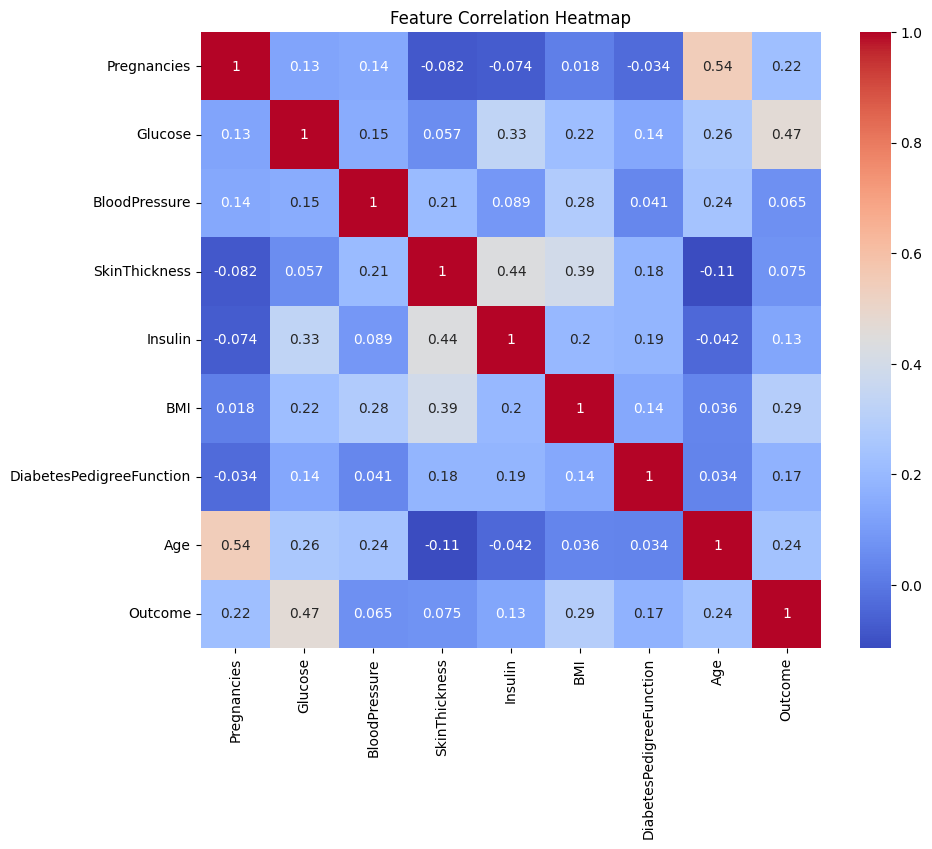

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

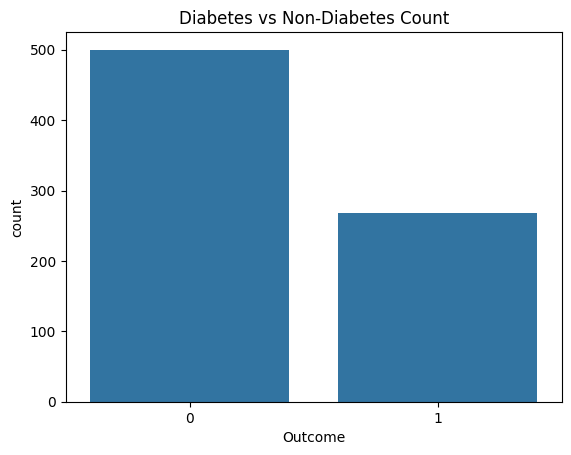

In [9]:
sns.countplot(x='Outcome', data=data)
plt.title("Diabetes vs Non-Diabetes Count")
plt.show()

In [10]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7532467532467533


In [14]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7597402597402597


In [15]:
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nClassification Report:\n", classification_report(y_test, rf_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, rf_pred))

Confusion Matrix:
 [[79 20]
 [17 38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81        99
           1       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

ROC-AUC Score: 0.7444444444444445


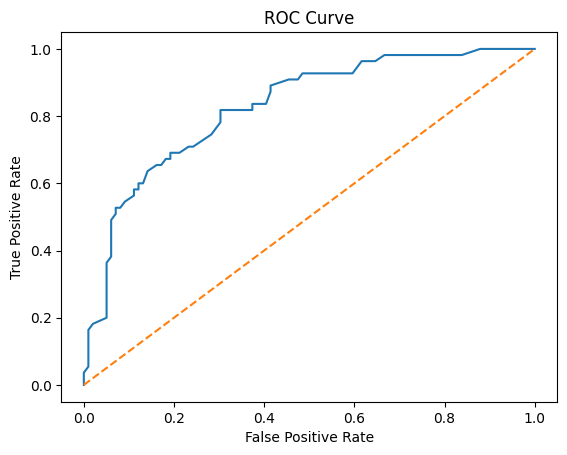

In [16]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [17]:
def predict_diabetes(input_data):
    input_array = np.array(input_data).reshape(1,-1)
    input_scaled = scaler.transform(input_array)
    
    probability = rf_model.predict_proba(input_scaled)[0][1]
    
    print("Risk Percentage:", round(probability*100,2), "%")
    
    if probability < 0.3:
        print("Low Risk")
    elif probability < 0.7:
        print("Medium Risk")
    else:
        print("High Risk")

In [18]:
sample = [2,120,70,20,80,25,0.5,30]
predict_diabetes(sample)

Risk Percentage: 7.0 %
Low Risk


C:\Users\soham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
!pip install ipywidgets


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import ipywidgets as widgets
from IPython.display import display

In [21]:
pregnancies = widgets.IntText(description="Pregnancies:")
glucose = widgets.FloatText(description="Glucose:")
bp = widgets.FloatText(description="BloodPressure:")
skin = widgets.FloatText(description="SkinThickness:")
insulin = widgets.FloatText(description="Insulin:")
bmi = widgets.FloatText(description="BMI:")
dpf = widgets.FloatText(description="DPF:")
age = widgets.IntText(description="Age:")

predict_button = widgets.Button(description="Predict Risk", button_style='success')
output = widgets.Output()

In [22]:
def on_button_clicked(b):
    with output:
        output.clear_output()
        
        input_data = [[
            pregnancies.value,
            glucose.value,
            bp.value,
            skin.value,
            insulin.value,
            bmi.value,
            dpf.value,
            age.value
        ]]
        
        input_scaled = scaler.transform(input_data)
        probability = rf_model.predict_proba(input_scaled)[0][1]
        risk_percentage = round(probability * 100, 2)
        
        print("🔍 Diabetes Risk Percentage:", risk_percentage, "%")
        
        if probability < 0.3:
            print("🟢 Low Risk")
            print("Maintain healthy lifestyle.")
        elif probability < 0.7:
            print("🟡 Medium Risk")
            print("Improve diet & exercise. Consult doctor.")
        else:
            print("🔴 High Risk")
            print("Immediate medical consultation recommended.")

predict_button.on_click(on_button_clicked)

In [23]:
display(
    pregnancies,
    glucose,
    bp,
    skin,
    insulin,
    bmi,
    dpf,
    age,
    predict_button,
    output
)

IntText(value=0, description='Pregnancies:')

FloatText(value=0.0, description='Glucose:')

FloatText(value=0.0, description='BloodPressure:')

FloatText(value=0.0, description='SkinThickness:')

FloatText(value=0.0, description='Insulin:')

FloatText(value=0.0, description='BMI:')

FloatText(value=0.0, description='DPF:')

IntText(value=0, description='Age:')

Button(button_style='success', description='Predict Risk', style=ButtonStyle())

Output()

In [24]:
import pickle

pickle.dump(rf_model, open("diabetes_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))